# Model 2: XGBoost

Gradient-boosted tree model predicting concentration-driven portfolio risk, compared against Model 1 (Logistic Regression) as a more complex, potentially higher-performing alternative.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import joblib
import os

In [2]:
import xgboost
print(xgboost.__version__)

2.0.3


## Configuration and Data Load

Uses the same `model_features.csv` and identical time-based train/test split as Model 1, ensuring a fair, directly comparable evaluation.

In [3]:
PROCESSED_DATA_DIR = "../../data/processed"
ARTIFACTS_DIR = "../../artifacts"
REPORTS_DIR = "../../reports"

model_data = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "model_features.csv"))

quarter_order = ["2015-03", "2015-06", "2015-09", "2015-12",
                  "2016-03", "2016-06", "2016-09", "2016-12",
                  "2017-03", "2017-06"]

train_quarters = quarter_order[:-2]
test_quarters = quarter_order[-2:]

train_df = model_data[model_data["quarter"].isin(train_quarters)].copy()
test_df = model_data[model_data["quarter"].isin(test_quarters)].copy()

feature_cols = ["hhi", "top_holding_pct", "num_holdings", "sector_hhi", "total_value"]
X_train, y_train = train_df[feature_cols], train_df["label"]
X_test, y_test = test_df[feature_cols], test_df["label"]

print(f"Train: {len(X_train)} rows, {y_train.mean():.1%} positive")
print(f"Test: {len(X_test)} rows, {y_test.mean():.1%} positive")

Train: 15151 rows, 4.8% positive
Test: 5093 rows, 2.2% positive


## Fit Model

No feature scaling is required, tree-based models split on raw feature values and are insensitive to scale. `scale_pos_weight` compensates for label imbalance, XGBoost's standard mechanism for this, analogous to Logistic Regression's `class_weight="balanced"`.

In [4]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

model2 = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)
model2.fit(X_train, y_train)

print("Model fitted.")

scale_pos_weight: 19.7
Model fitted.


## Feature Importance

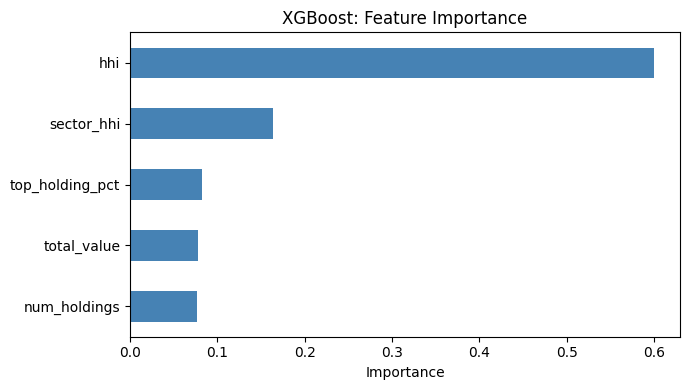

num_holdings       0.076644
total_value        0.078213
top_holding_pct    0.082420
sector_hhi         0.163164
hhi                0.599559
dtype: float32


In [5]:
importances = pd.Series(model2.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("XGBoost: Feature Importance")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_feature_importance.png"), dpi=100)
plt.show()

print(importances)

## Evaluate on Test Set

              precision    recall  f1-score   support

           0       1.00      0.79      0.88      4979
           1       0.09      0.93      0.17       114

    accuracy                           0.80      5093
   macro avg       0.55      0.86      0.53      5093
weighted avg       0.98      0.80      0.87      5093


Confusion Matrix:
[[3950 1029]
 [   8  106]]

ROC-AUC: 0.926


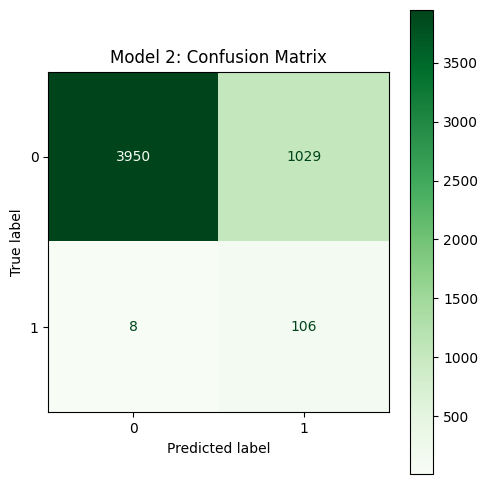

In [6]:
y_pred = model2.predict(X_test)
y_pred_proba = model2.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred)}')
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap="Greens")
ax.set_title("Model 2: Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model2_confusion_matrix.png"), dpi=100)
plt.show()

ROC-AUC (0.926) is marginally higher than Model 1's 0.919, essentially equivalent ranking performance between the two models. Recall (0.93) is close to Model 1's 0.88, while precision (0.09) is slightly lower than Model 1's 0.12, both consequences of `scale_pos_weight` compensating for the same class imbalance.

## Save Model

In [10]:
joblib.dump(model2, os.path.join(ARTIFACTS_DIR, "model2_xgboost.pkl"))
print("Model 2 saved.")

Model 2 saved.


## Model Comparison Chart

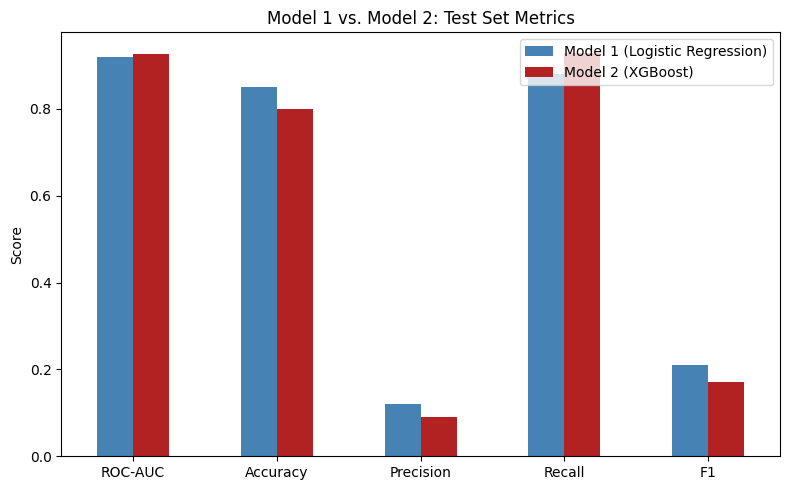

In [7]:
comparison_metrics = pd.DataFrame({
    "Model 1 (Logistic Regression)": [0.919, 0.85, 0.12, 0.88, 0.21],
    "Model 2 (XGBoost)": [0.926, 0.80, 0.09, 0.93, 0.17]
}, index=["ROC-AUC", "Accuracy", "Precision", "Recall", "F1"])

fig, ax = plt.subplots(figsize=(8, 5))
comparison_metrics.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_ylabel("Score")
ax.set_title("Model 1 vs. Model 2: Test Set Metrics")
ax.legend(loc="upper right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "charts", "model_comparison.png"), dpi=100)
plt.show()